# LAB 2 – Đặc trưng tiếng nói và nhận dạng bằng DTW
**CSE457 – Xử lý âm thanh và tiếng nói**

Bài thực hành sử dụng 25 file WAV của 5 từ: **không, một, hai, ba, bốn**, mỗi từ 5 lần ghi.

Pipeline: chuẩn hóa 16 kHz → frame/Hamming → Energy + ZCR → endpoint detection → pre-emphasis → MFCC → Euclidean distance → tự cài DTW → nearest-template → accuracy/confusion matrix.

> Chia dữ liệu: 3 file đầu mỗi từ làm template training, 2 file cuối làm test



In [2]:
# Nếu chạy trên Google Colab và cần cài thư viện:
# !pip install numpy scipy matplotlib librosa soundfile scikit-learn numba

from pathlib import Path
import sys
import pandas as pd
ROOT = Path.cwd()
if not (ROOT / "lab2.py").exists():
    raise FileNotFoundError("Hãy mở notebook từ thư mục Lab2_MFCC_DTW.")
from lab2 import *
DATA = ROOT / "dataset"
FIG = ROOT / "figures"
RES = ROOT / "results"
FIG.mkdir(exist_ok=True); RES.mkdir(exist_ok=True)

print("Dataset:", sum(1 for _ in DATA.glob("*/*.wav")), "WAV files")
for lab in LABELS:
    print(lab, ":", len(list((DATA/lab).glob("*.wav"))), "files")


Dataset: 25 WAV files
khong : 5 files
mot : 5 files
hai : 5 files
ba : 5 files
bon : 5 files


## A–B. Kiểm tra dữ liệu, waveform, Energy và ZCR

In [3]:
samples = [
    DATA/'ba'/'ba_01.wav',
    DATA/'mot'/'mot_01.wav',
    DATA/'khong'/'khong_01.wav'
]
for p in samples:
    y = load_audio(p)
    print(p.name, "duration =", round(len(y)/FS, 3), "s", "samples =", len(y))
    plot_wave_energy_zcr(p, FIG/f'{p.parent.name}_energy_zcr.png')


ba_01.wav duration = 5.013 s samples = 80213
mot_01.wav duration = 4.843 s samples = 77482
khong_01.wav duration = 6.571 s samples = 105130


**Nhận xét:** silence có năng lượng/RMS thấp; vùng voiced thường có năng lượng cao và ZCR thấp hơn. Unvoiced/fricative có thể có năng lượng thấp hơn nhưng ZCR cao hơn. Đây là lý do Lab kết hợp energy với ZCR khi làm endpoint detection. fileciteturn0file0L124-L147

## C. Endpoint detection

In [4]:
rows=[]
for p in sorted(DATA.glob('*/*.wav')):
    y=load_audio(p)
    yt,(s,e)=trim_energy(y)
    rows.append([p.parent.name,p.name,len(y)/FS,len(yt)/FS])
endpoint_df = pd.DataFrame(rows, columns=['label','file','before_s','after_trim_s'])
display(endpoint_df.head(10))
print("Ngưỡng endpoint:", TOP_DB, "dB; margin:", MARGIN_MS, "ms")
endpoint_df.to_csv(RES/'endpoint_durations.csv',index=False,encoding='utf-8-sig')


,label,file,before_s,after_trim_s
0,ba,ba_01.wav,5.013312,4.733313
1,ba,ba_02.wav,4.799938,4.519938
2,ba,ba_03.wav,4.671938,4.391938
3,ba,ba_04.wav,5.439938,5.159937
4,ba,ba_05.wav,4.586625,4.306625
5,bon,bon_01.wav,4.394687,4.104687
6,bon,bon_02.wav,5.226625,4.946625
7,bon,bon_03.wav,4.821313,4.541313
8,bon,bon_04.wav,4.650625,4.370625
9,bon,bon_05.wav,4.629313,4.349312


Ngưỡng endpoint: 35 dB; margin: 50 ms


## D. MFCC

In [5]:
for p in [samples[0], samples[1]]:
    y,_=trim_energy(load_audio(p))
    M=mfcc_feature(y)
    print(p.name, "MFCC shape =", M.shape, "(frames, 13)")
    plot_mfcc(p, FIG/f'{p.parent.name}_mfcc.png')


ba_01.wav MFCC shape = (471, 13) (frames, 13)
mot_01.wav MFCC shape = (454, 13) (frames, 13)


**Tham số:** frame 25 ms, hop 10 ms, Hamming, pre-emphasis α=0.97, NFFT=512, 24 Mel filters, 13 MFCC và CMN. Các tham số phải giữ nhất quán giữa train/test. fileciteturn0file0L235-L243

## E. DTW – tự cài đặt

In [6]:
def feat(p):
    y,_=trim_energy(load_audio(p))
    return mfcc_feature(y)

X_same=feat(DATA/'ba'/'ba_04.wav')
Y_same=feat(DATA/'ba'/'ba_05.wav')
X_diff=feat(DATA/'ba'/'ba_04.wav')
Y_diff=feat(DATA/'bon'/'bon_04.wav')

same = plot_dtw(X_same,Y_same,'Same word: ba_04 vs ba_05',FIG/'dtw_same_word.png')
diff = plot_dtw(X_diff,Y_diff,'Different words: ba_04 vs bon_04',FIG/'dtw_different_word.png')
print("DTW_norm cùng từ =", round(same,4))
print("DTW_norm khác từ =", round(diff,4))


DTW_norm cùng từ = 20.204
DTW_norm khác từ = 27.7368


DTW dùng recurrence `D[i,j] = C[i,j] + min(...)`, sau đó backtracking từ ô cuối và chuẩn hóa theo độ dài đường đi. fileciteturn0file0L189-L203

## F–G. Nearest-template và đánh giá

Accuracy = 90.00%


,test_file,true_label,pred_label,correct,top1_dtw,top2_dtw,top3_dtw
0,khong_04.wav,không,không,True,23.465223,23.624555,26.112827
1,khong_05.wav,không,không,True,24.340643,25.503044,25.811872
2,mot_04.wav,một,một,True,20.787439,22.820526,23.411749
3,mot_05.wav,một,bốn,False,23.111834,23.162638,23.848831
4,hai_04.wav,hai,hai,True,25.971207,26.423245,26.630542
5,hai_05.wav,hai,hai,True,27.852042,29.140223,29.478242
6,ba_04.wav,ba,ba,True,23.883345,24.414386,25.007606
7,ba_05.wav,ba,ba,True,23.267391,24.791933,26.362617
8,bon_04.wav,bốn,bốn,True,22.400349,22.725463,23.713419
9,bon_05.wav,bốn,bốn,True,22.130850,24.421436,24.632331


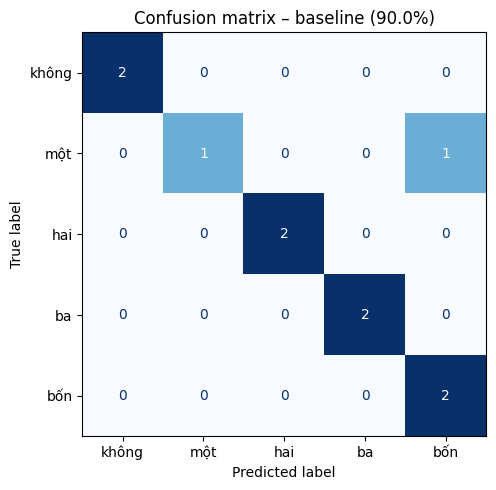

In [7]:
acc, cm, rows, templates = evaluate(DATA, trim=True, use_delta=False)
save_results(rows, RES/'results_baseline.csv')
print(f"Accuracy = {acc*100:.2f}%")
display(pd.DataFrame(rows, columns=['test_file','true_label','pred_label','correct','top1_dtw','top2_dtw','top3_dtw']))
fig,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm,display_labels=[VN[x] for x in LABELS]).plot(
    ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title(f'Confusion matrix – baseline ({acc*100:.1f}%)')
plt.tight_layout(); plt.show()


## Thí nghiệm E1 – Không trim vs. có trim

In [8]:
acc_nt, cm_nt, rows_nt, _ = evaluate(DATA, trim=False, use_delta=False)
save_results(rows_nt, RES/'results_no_trim.csv')
print(f"Không endpoint trim: {acc_nt*100:.2f}%")
print(f"Có endpoint trim:    {acc*100:.2f}%")


Không endpoint trim: 90.00%
Có endpoint trim:    90.00%


## Thí nghiệm E2 – MFCC 13 vs. MFCC + Δ

In [9]:
acc_delta, cm_delta, rows_delta, _ = evaluate(DATA, trim=True, use_delta=True)
save_results(rows_delta, RES/'results_mfcc_delta.csv')
print(f"MFCC 13:       {acc*100:.2f}%")
print(f"MFCC 13 + Δ:   {acc_delta*100:.2f}%")


MFCC 13:       90.00%
MFCC 13 + Δ:   100.00%


## Kết luận và trả lời câu hỏi báo cáo

1. **Vì sao không dùng toàn bộ waveform làm template?** Vì cùng một từ có thể có số mẫu/thời lượng khác nhau; DTW xử lý tốt hơn sự co giãn theo thời gian trên chuỗi đặc trưng.

2. **Energy và ZCR khác nhau thế nào?** Energy/RMS phản ánh mức năng lượng của frame; ZCR phản ánh mức độ đổi dấu. Energy hữu ích để phát hiện vùng speech, còn ZCR hỗ trợ phân biệt/điều chỉnh các vùng có âm vô thanh.

3. **Vì sao Mel filterbank giãn rộng theo Hz ở tần số cao?** Thang Mel phân bố độ phân giải theo cảm nhận thính giác: vùng thấp được phân giải dày hơn, vùng cao thưa hơn.

4. **Vai trò của log và DCT trong MFCC?** Log nén dynamic range của năng lượng filterbank; DCT biến các log-energy filterbank thành các hệ số cepstral, trong đó các hệ số đầu mô tả dạng bao phổ ngắn hạn.

5. **Ba bước DTW?** Bước ngang giữ frame template và tăng frame test; bước dọc tăng frame template và giữ frame test; bước chéo tăng cả hai. Đường đi phải đơn điệu theo thời gian.

6. **Vì sao chuẩn hóa DTW theo path length?** Để giảm thiên lệch khiến chuỗi dài có tổng cost lớn hơn chỉ vì có nhiều cặp frame.

7. **Ba nguyên nhân MFCC cùng một từ khác nhau:** tốc độ nói, cao độ/cường độ và cách phát âm; ngoài ra còn có microphone/kênh thu và nhiễu nền.

8. **Phân tích nhầm lẫn:** dùng confusion matrix và top-3 DTW scores trong `results_baseline.csv` để xác định cặp dễ nhầm nhất; sau đó đối chiếu waveform, MFCC và DTW path.

9. **Hạn chế với người nói mới:** DTW nearest-template phụ thuộc vào template của người nói/kênh thu. Cross-speaker thường làm khoảng cách tăng; các mô hình âm học ở chương sau phù hợp hơn cho bài toán tổng quát hóa người nói.


## Các file đầu ra

- `figures/*_energy_zcr.png`: waveform + log-energy + ZCR.
- `figures/*_mfcc.png`: MFCC heatmap.
- `figures/dtw_same_word.png`, `dtw_different_word.png`: local-distance matrix + optimal path.
- `figures/confusion_matrix_baseline.png`: confusion matrix.
- `results/results_baseline.csv`: nhãn thật, dự đoán và top-3 DTW.
- `results/results_no_trim.csv`: E1.
- `results/results_mfcc_delta.csv`: E2.
- `results/summary.csv`: tóm tắt các kết quả chính.
